In [1]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, print_wise, get_lagplot, compatible_TimeSeries_check
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.regression import dyn_linear_encoding
from useful_stuff.general_utils.II import dynInformationImbalance
from project_specific_utils.dataloader import load_meg_data, load_concat_regressout_meg, load_concat_regressout_mod
from image_processing.gaze_dep_models import save_ANN_features
from analyses.subsampling_lagged_comparisons import save_lagged_comparisons, get_spaced_pseudotrials


In [60]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 3
    run = 1
    neu_fs = 100
    gaze_fs = 50
    mod_fs = 23.976
    model_name = "vit_l_16";
    layer_name = "classifier.2";
    n_components = 1000
    pooling = "all"
    sq_side = 384
    repetition = 0
    downsampled_sq_size = 50
    sensors_group = 'occ'
    time_points = 50
    regress_out_gaze = "PCR"
    PCs_to_regress_out = 50
    timepts_to_regress_out = 50
    max_lag=100
    pkg="timm"
    analysis_type = "encoding"
    regression_type = "ridge"
    score_type = "corr"
    n_model_components = 1000
    model_PCs_to_keep = 50

cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, pkg=cfg.pkg)

In [61]:
rank = 0
n = load_concat_regressout_meg(paths, cfg.sub_num, cfg.repetition, cfg.sensors_group, cfg.neu_fs, cfg.gaze_fs, cfg.regress_out_gaze, cfg.PCs_to_regress_out, timepts_to_regress_out=(-cfg.timepts_to_regress_out, cfg.timepts_to_regress_out), rank=rank)
n.z_score_feats()
n = TimeSeries(n.get_array()[:, :, np.newaxis], cfg.neu_fs)

12:19:55 - rank 0 Loading MEG signal: regress_out_gaze='PCR'
12:19:56 - rank 0 Shape runs [1 2 3]: [(41, 87379), (41, 86278), (41, 79071)]


In [ ]:
from scipy.io import loadmat, savemat
def lagged_encoding_comparisons(paths, rank, full_model_name, n, analysis_type, sub_num, sensors_group, repetition, max_lag, neu_fs, mod_fs, regression_type, score_type, sq_side, regress_out_gaze, n_model_components, model_PCs_to_keep, pooling="all",):
    regress_out_type = regress_out_gaze if regress_out_gaze else "0"
    p = save_lagged_comparisons(paths, analysis_type, sub_num, sensors_group, repetition, full_model_name, None, max_lag, neu_fs, regression_type=regression_type, score_metric=score_type, PCs_used=model_PCs_to_keep, sq_side=sq_side, regress_out_gaze=regress_out_type)
    if os.path.exists(p):
        print(f"{p} already exists")
        return None
    mod_fs = config["movie_fs"]
    m = load_concat_regressout_mod(paths, sub_num, save_ANN_features, full_model_name, repetition, mod_fs, neu_fs, *(sq_side, n_model_components, pooling), regress_out_gaze=False, gaze_dep=True, gaze_fs=50, rank=rank,)
    m = TimeSeries(m.get_array()[:model_PCs_to_keep, :, np.newaxis], neu_fs)
    regression_obj = dyn_linear_encoding(regression_type, 'kf', max_lag, score_type=score_type, n_splits=2)
    s = regression_obj.crossvalidate_general_dyn(m, n)
    savemat(p, {"encoding": s.get_array()})
    print_wise(f"{full_model_name} saved at {p}")
    return None
# EOF


In [63]:
full_model_name = f"{cfg.model_name}_{layers[20]}"
lagged_encoding_comparisons(paths, rank, full_model_name, n, cfg.analysis_type, cfg.sub_num, cfg.sensors_group, cfg.repetition, cfg.max_lag, cfg.neu_fs, cfg.mod_fs, cfg.regression_type, cfg.score_type, cfg.sq_side, cfg.regress_out_gaze, cfg.n_model_components, cfg.model_PCs_to_keep, pooling=cfg.pooling,)

12:19:58 - rank 0 Loading model vit_l_16_blocks.20.mlp.fc2: regress_out_gaze=False
12:19:59 - rank 0 vit_l_16_blocks.20.mlp.fc2: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
12:33:02 - vit_l_16_blocks.20.mlp.fc2 saved at /Users/tizianocausin/1917_local/results/encoding_sub003_occ_rep0_vit_l_16_blocks.20.mlp.fc2_50PCs_ridge_corr_lag_1s_384x384patch_regr_out_gaze_PCR.mat


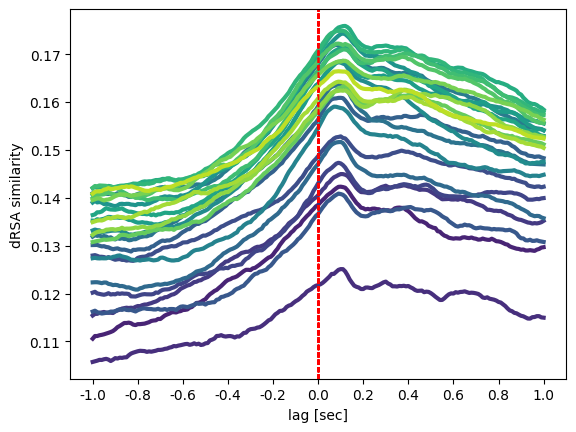

In [93]:
from useful_stuff.general_utils.plots import truncate_colormap
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, 24))
lagplots = []
centroids = []
peaks = []
tick_step = 20
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, tick_step)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += cfg.max_lag
for i in range(24):
    s = loadmat(f"/Users/tizianocausin/1917_local/results/encoding_sub003_occ_rep0_dino_v3_l_layer.{i}.mlp.down_proj_50PCs_ridge_corr_lag_1s_384x384patch_regr_out_gaze_PCR.mat")
    # print(s["encoding"].shape)
    lagplot =np.squeeze(s["encoding"])
    lagplots.append(lagplot)
    # --- compute peak ---
    peak_idx = np.argmax(lagplot)
    lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)

    weights = lagplot.copy()
    weights[weights < 0] = 0  # optional but recommended

    centroid = np.sum(lags * weights) / np.sum(weights)
    centroid_lag = np.round(centroid / cfg.neu_fs, 2)
    peak_val = lagplot[peak_idx]
    peak_lag = (peak_idx - cfg.max_lag) / cfg.neu_fs  # convert to seconds
    peaks.append(peak_lag)
    centroids.append(centroid_lag)
    plt.plot(lagplot, linewidth=3, label=f"Block {i} - p={peak_lag}sec; c={centroid_lag}sec", color=colors[i])
    plt.ylabel("dRSA similarity")
    plt.xlabel("lag [sec]")
    plt.xticks(ticks, ticks_labels)
    plt.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)



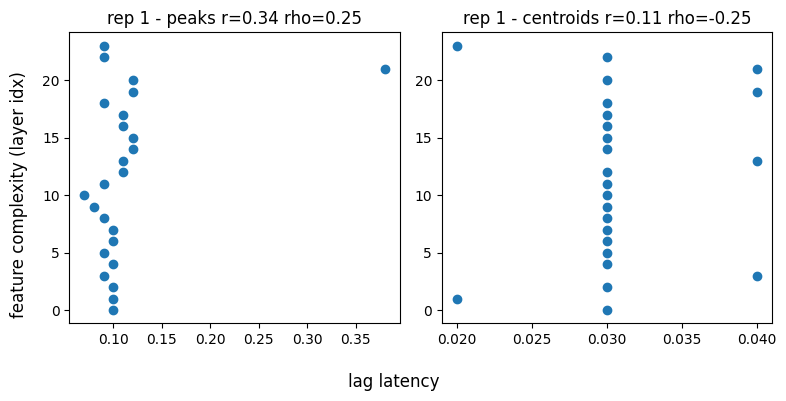

In [94]:
from useful_stuff.general_utils.utils import spearman
max_lag = 200
tick_step = 40
fig, ax = plt.subplots(1,2, figsize=(8, 4))
ax[0].scatter(np.array(peaks), np.arange(len(peaks)))
rho = np.round(spearman(np.arange(len(peaks)), np.array(peaks)),2)
r = round(np.corrcoef(np.arange(len(peaks)), np.array(peaks))[0,1],2)
ax[0].set_title(f"rep {cfg.repetition+1} - peaks r={r} rho={rho}")
ax[1].scatter(centroids, np.arange(len(centroids)));
rho = np.round(spearman(np.arange(len(peaks)), np.array(centroids)), 2)
r = round(np.corrcoef(np.arange(len(centroids)), np.array(centroids))[0,1],2)
ax[1].set_title(f"rep {cfg.repetition+1} - centroids r={r} rho={rho}")
fig.supxlabel("lag latency")
fig.supylabel("feature complexity (layer idx)")
fig.tight_layout()

In [28]:
sub_num = 3; run = 1;
tot_crossval = []
for l in layers:
    try:
        print_wise(f"starting layer {l}")
        ANN_features_path = save_ANN_features(paths, f"{cfg.model_name}_{l}", cfg.mod_fs, sub_num, run, cfg.n_components, cfg.sq_side, cfg.pooling,)
        with h5py.File(ANN_features_path, "r") as f:
            features = TimeSeries(f['vecrep'][:, :], cfg.mod_fs)
            features.resample(cfg.neu_fs)
        features_reduced = TimeSeries(features.get_array()[:50, :], cfg.mod_fs)
        X = TimeSeries(features_reduced.get_array()[:,:,np.newaxis], neu_rep1.get_fs())
        Y = TimeSeries(neu_rep1.get_array()[:,:len(features_reduced),np.newaxis], neu_rep1.get_fs())
        model = dyn_linear_encoding('ridge', 'kf', cfg.max_lag, score_type="corr")
        # X.z_score_feats()
        s = model.crossvalidate_general_dyn(X, Y)
        tot_crossval.append(s)
    except FileNotFoundError:
            print_wise(f"{l} not found")
os.system('afplay /System/Library/Sounds/Ping.aiff')

10:21:09 - starting layer blocks.0.mlp.fc2
10:29:08 - starting layer blocks.1.mlp.fc2
11:34:12 - starting layer blocks.2.mlp.fc2
11:59:02 - starting layer blocks.3.mlp.fc2
12:28:13 - starting layer blocks.4.mlp.fc2
12:58:15 - starting layer blocks.5.mlp.fc2
13:35:28 - starting layer blocks.6.mlp.fc2
14:03:42 - starting layer blocks.7.mlp.fc2
14:32:44 - starting layer blocks.8.mlp.fc2
15:14:47 - starting layer blocks.9.mlp.fc2
15:53:10 - starting layer blocks.10.mlp.fc2
16:01:07 - starting layer blocks.11.mlp.fc2
16:09:05 - starting layer blocks.12.mlp.fc2
16:17:07 - starting layer blocks.13.mlp.fc2
16:25:01 - starting layer blocks.14.mlp.fc2
16:32:58 - starting layer blocks.15.mlp.fc2
16:40:50 - starting layer blocks.16.mlp.fc2
16:48:48 - starting layer blocks.17.mlp.fc2
16:56:43 - starting layer blocks.18.mlp.fc2
17:04:34 - starting layer blocks.19.mlp.fc2
17:12:25 - starting layer blocks.20.mlp.fc2
17:20:14 - starting layer blocks.21.mlp.fc2
17:28:05 - starting layer blocks.22.mlp.fc

0

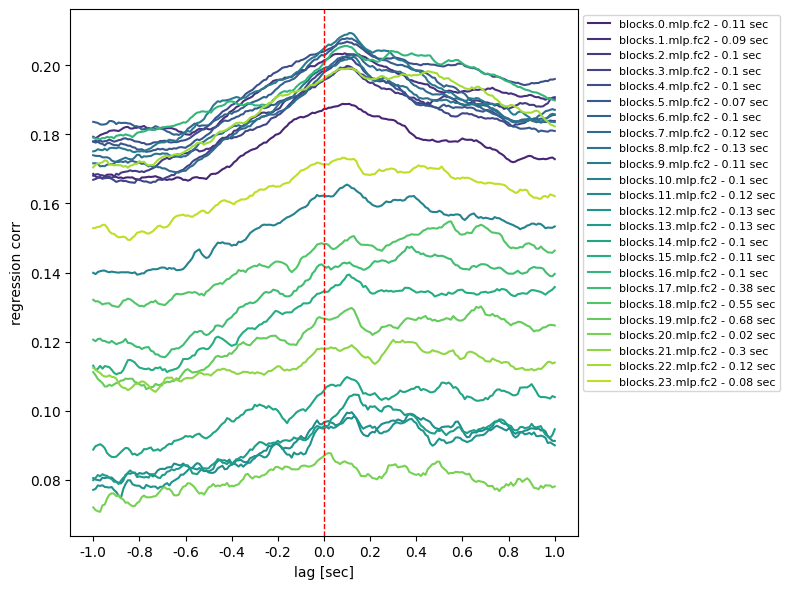

In [29]:
from useful_stuff.general_utils.plots import truncate_colormap
peaks = []
centroids = []
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, 20)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += cfg.max_lag
plt.figure(figsize=(8, 6))
lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, len(tot_crossval)))
for idx, l in enumerate(tot_crossval):
    curve = np.squeeze(l.get_array())
    weights = l.get_array().copy()
    weights[weights < 0] = 0  # optional but recommended
    centroid = np.sum(lags * weights) / np.sum(weights)
    centroid_lag = np.round(centroid / cfg.neu_fs, 2)
    centroids.append(centroid_lag)
    peaks.append((np.argmax(curve) - cfg.max_lag)/cfg.neu_fs)
    plt.plot(curve, label=f"{layers[idx]} - {peaks[-1]} sec", color=colors[idx])
plt.xticks(ticks, ticks_labels)
plt.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
plt.xlabel("lag [sec]")
plt.ylabel("regression corr")
plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()